# 04 — Macro & CAT Sensitivity (Scenario Thinking)

## What this notebook delivers
We answer three governance questions on a frozen UK personal-lines synthetic portfolio:

1) **Severity channel**: do losses increase when inflation/repair costs rise (direction + magnitude)?
2) **Frequency channel**: do catastrophe months increase claim counts (event-rate shock)?
3) **Scenario translation**: if macro moves, what happens to portfolio loss — **gross and by product**, with **uncertainty bands**?

## Output artifacts
- Elasticity table (+ 95% CI): inflation & repair → severity
- CAT uplift: catastrophe_flag → frequency multiplier
- Product-level sensitivities (where risk concentrates)
- Scenario deltas: baseline vs shocks
- Uncertainty: bootstrap bands for scenario impacts

## Executive decision framing

**Decision question this analysis answers:**

> Under which macroeconomic and catastrophe conditions does the portfolio experience
> material deterioration in paid losses, and how effectively does the current
> reinsurance structure stabilise net outcomes?

This notebook translates macro stress into **financial impact**, not model artefacts.

In [1]:
# Imports & display defaults

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

sns.set_style("whitegrid")
pd.options.display.float_format = "{:,.4f}".format

In [2]:
# Load frozen datasets

DATA_PATH = "../data/raw"

macro = pd.read_csv(f"{DATA_PATH}/macro.csv", parse_dates=["month"])
holders = pd.read_csv(f"{DATA_PATH}/policyholders.csv")
policies = pd.read_csv(f"{DATA_PATH}/policies.csv", parse_dates=["start_date", "end_date"])
claims = pd.read_csv(f"{DATA_PATH}/claims.csv", parse_dates=["incident_date", "reported_date"])

print("macro:", macro.shape)
print("holders:", holders.shape)
print("policies:", policies.shape)
print("claims:", claims.shape)

display(macro.head(3))
display(claims.head(3))

macro: (84, 5)
holders: (80000, 8)
policies: (120000, 11)
claims: (148907, 12)


,month,inflation_index,unemployment_rate,repair_cost_index,catastrophe_flag
0,2018-01-01,1.0021,0.0490,0.9539,0
1,2018-02-01,1.0042,0.0627,1.0325,0
2,2018-03-01,1.0063,0.0684,1.1174,0


,claim_id,policy_id,customer_id,incident_date,reported_date,claim_type,cause,status,paid_amount,outstanding_reserve,is_fraud,fraud_ring_id
0,1,2,52184,2022-11-11,2022-11-29,mechanical,synthetic_engine,repudiated,0.0000,0.0000,0,NaN
1,2,4,3503,2022-12-06,2022-12-06,medical,synthetic_engine,open,"16,780.8156","7,056.6919",0,NaN
2,3,5,46173,2019-11-13,2019-12-12,accident,synthetic_engine,closed,"3,798.6489",0.0000,0,NaN


In [3]:
# Data contract checks (governance guardrail)

req_macro = {"month", "inflation_index", "repair_cost_index", "unemployment_rate", "catastrophe_flag"}
req_claims = {"claim_id", "policy_id", "incident_date", "paid_amount"}

assert req_macro.issubset(macro.columns), f"macro missing: {req_macro - set(macro.columns)}"
assert req_claims.issubset(claims.columns), f"claims missing: {req_claims - set(claims.columns)}"

assert macro["catastrophe_flag"].dropna().isin([0,1]).all(), "catastrophe_flag must be 0/1"
assert claims["incident_date"].notna().all(), "incident_date missing"

In [4]:
# Build monthly macro join (the correct grain for scenario governance)

macro2 = macro.copy()
macro2["ym"] = pd.to_datetime(macro2["month"]).dt.to_period("M")

clm = claims.copy()
clm["ym"] = pd.to_datetime(clm["incident_date"]).dt.to_period("M")

# Join claims -> macro (many claims per month)
clm = clm.merge(
    macro2[["ym", "inflation_index", "repair_cost_index", "unemployment_rate", "catastrophe_flag"]],
    on="ym",
    how="left",
    validate="many_to_one"
)

# Attach product_type for product-level decomposition
clm = clm.merge(
    policies[["policy_id", "product_type"]],
    on="policy_id",
    how="left",
    validate="many_to_one"
)

coverage = clm["inflation_index"].notna().mean()
print(f"Macro linkage coverage: {coverage:.2%}")
assert coverage > 0.95, "Too many claims not mapped to macro months"

Macro linkage coverage: 100.00%


## Executive framing: frequency vs severity channels

In pricing and capital, we treat loss as:

- **Frequency** (how many claims happen)  
- **Severity** (how big each claim is)

Macro and CAT can hit either channel:

- Inflation / repair costs → typically **severity**
- Catastrophe months → typically **frequency** (more events)

We explicitly model and validate both channels.

In [5]:
# Build modelling datasets (severity & frequency)

# ---- Severity view (positive paid only) ----
sev = clm.loc[clm["paid_amount"] > 0].copy()

# Winsorise severity to reduce undue influence of outliers (keeps tail but avoids domination)
p_lo, p_hi = sev["paid_amount"].quantile([0.01, 0.99])
sev["paid_w"] = sev["paid_amount"].clip(lower=p_lo, upper=p_hi)

sev["log_paid"] = np.log(sev["paid_w"])
sev["log_infl"] = np.log(sev["inflation_index"])
sev["log_repair"] = np.log(sev["repair_cost_index"])

# ---- Frequency view (month x product) ----
freq = (
    clm.groupby(["product_type", "ym"])
    .agg(
        claim_count=("claim_id", "count"),
        inflation=("inflation_index", "mean"),
        repair=("repair_cost_index", "mean"),
        unemp=("unemployment_rate", "mean"),
        cat=("catastrophe_flag", "max"),
    )
    .reset_index()
)

freq["log_infl"] = np.log(freq["inflation"])
freq["log_repair"] = np.log(freq["repair"])


In [6]:
# Severity model (elasticities + robust SE)

X = sev[["log_infl", "log_repair", "unemployment_rate", "catastrophe_flag"]].copy()
X = sm.add_constant(X)
y = sev["log_paid"]

sev_model = sm.OLS(y, X).fit(cov_type="HC3")  # robust SE
print(sev_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_paid   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     2879.
Date:                Sat, 07 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:07:03   Log-Likelihood:            -1.9421e+05
No. Observations:              134309   AIC:                         3.884e+05
Df Residuals:                  134304   BIC:                         3.885e+05
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 7.5326      0.01

In [7]:
# Clean coefficient table (+ 95% CI) for severity

def coef_table(model):
    out = pd.DataFrame({
        "coef": model.params,
        "se": model.bse,
        "t": model.tvalues,
        "p": model.pvalues
    })
    ci = model.conf_int(alpha=0.05)
    out["ci_low"] = ci[0]
    out["ci_high"] = ci[1]
    return out

sev_coef = coef_table(sev_model).loc[["log_infl", "log_repair", "unemployment_rate", "catastrophe_flag"]]
display(sev_coef)

,coef,se,t,p,ci_low,ci_high
log_infl,0.1725,0.0215,8.0057,0.0000,0.1302,0.2147
log_repair,0.7896,0.0223,35.3696,0.0000,0.7458,0.8334
unemployment_rate,-1.7270,0.3308,-5.2213,0.0000,-2.3753,-1.0787
catastrophe_flag,0.0581,0.0248,2.3367,0.0195,0.0094,0.1067


## Severity elasticities — actuarial interpretation

We modelled log(claim severity) as a function of macro drivers using robust (HC3) errors.

Key findings:

- **Repair costs dominate severity dynamics**  
  A 10% increase in the repair cost index implies an ~8% increase in average paid severity, consistent with post-COVID UK motor and property experience.

- **General inflation has a secondary but material effect**  
  Inflation elasticity is positive but lower than repair costs, reflecting that claims are driven more by sector-specific cost pressures than CPI.

- **Economic downturn effects are visible**  
  Higher unemployment is associated with lower observed severity, consistent with behavioural and utilisation effects.

- **Catastrophes primarily act through frequency, not severity**  
  CAT months show a small but positive severity uplift, supporting the modelling assumption that CATs are predominantly frequency shocks.

Although overall R² is modest, this is expected at claim level; the model is fit for purpose as an **elasticity estimation tool** for pricing and scenario analysis rather than point prediction.

In [8]:
# 1️⃣ Prepare modelling dataset (governance: explicit filtering)
df = (
    freq
    .dropna(subset=["claim_count", "log_infl", "log_repair", "unemp", "cat", "product_type"])
    .copy()
)

# 2️⃣ Endogenous variable (claim counts)
yf = pd.to_numeric(df["claim_count"], errors="raise").astype(int)

# 3️⃣ Product fixed effects (force numeric dummies)
prod_dum = pd.get_dummies(
    df["product_type"],
    drop_first=True,
    prefix="prod",
    dtype=float
)

# 4️⃣ Assemble design matrix
Xf = pd.concat(
    [
        df[["cat", "log_infl", "log_repair", "unemp"]].astype(float),
        prod_dum
    ],
    axis=1
)

Xf = sm.add_constant(Xf, has_constant="add")

# 5️⃣ Final governance guardrails
Xf = Xf.apply(pd.to_numeric, errors="raise")

assert not Xf.dtypes.eq("object").any(), "❌ Xf contains non-numeric dtypes"
assert yf.dtype != object, "❌ yf is object dtype"

# -------------------------------
# Poisson baseline (dispersion check)
# -------------------------------
pois = sm.GLM(
    yf,
    Xf,
    family=sm.families.Poisson()
).fit(cov_type="HC3")

mu = pois.fittedvalues
pearson_chi2 = np.sum(((yf - mu) ** 2) / np.maximum(mu, 1e-9))
dispersion = pearson_chi2 / pois.df_resid

print(f"Poisson dispersion (Pearson χ² / dof): {dispersion:.2f}")

# -------------------------------
# Negative Binomial GLM
# -------------------------------
# Pragmatic actuarial choice:
# alpha ≈ (dispersion - 1), lower-bounded to avoid instability
alpha = max(dispersion - 1.0, 0.1)

nb = sm.GLM(
    yf,
    Xf,
    family=sm.families.NegativeBinomial(alpha=alpha)
).fit(cov_type="HC3")

print(nb.summary())

Poisson dispersion (Pearson χ² / dof): 88.06
                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:                  420
Model:                            GLM   Df Residuals:                      411
Model Family:        NegativeBinomial   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4148.6
Date:                Sat, 07 Feb 2026   Deviance:                       1.7078
Time:                        16:07:03   Pearson chi2:                     1.22
No. Iterations:                     6   Pseudo R-squ. (CS):           0.007807
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
c

In [9]:
# CAT uplift (frequency multiplier) + CI

nb_coef = coef_table(nb)
display(nb_coef.loc[["cat"]])

cat_beta = float(nb.params["cat"])
cat_uplift = np.exp(cat_beta) - 1.0
print(f"Implied CAT frequency uplift (ceteris paribus): {cat_uplift:.2%}")

,coef,se,t,p,ci_low,ci_high
cat,0.1555,0.0501,3.1020,0.0019,0.0572,0.2537


Implied CAT frequency uplift (ceteris paribus): 16.82%


In [10]:
# Product-specific severity elasticities (credible & guarded)

MIN_CLAIMS = 3000
prod_sev_models = {}
rows = []

for prod, dfp in sev.groupby("product_type"):
    if len(dfp) < MIN_CLAIMS:
        continue

    Xp = sm.add_constant(dfp[["log_infl", "log_repair", "unemployment_rate", "catastrophe_flag"]])
    yp = dfp["log_paid"]

    m = sm.OLS(yp, Xp).fit(cov_type="HC3")
    prod_sev_models[prod] = m

    ct = coef_table(m).loc[["log_infl", "log_repair"]].copy()
    ct["product_type"] = prod
    ct["term"] = ct.index
    rows.append(ct.reset_index(drop=True))

prod_sev_coef = pd.concat(rows, ignore_index=True)
display(prod_sev_coef.sort_values(["term","product_type"]))

,coef,se,t,p,ci_low,ci_high,product_type,term
0,0.3576,0.0789,4.5329,0.0000,0.2030,0.5123,gap,log_infl
2,0.1327,0.0294,4.5146,0.0000,0.0751,0.1903,health,log_infl
4,0.1201,0.0346,3.4671,0.0005,0.0522,0.1880,home,log_infl
6,0.1706,0.0215,7.9420,0.0000,0.1285,0.2127,motor,log_infl
8,0.1661,0.0321,5.1807,0.0000,0.1033,0.2290,warranty,log_infl
1,0.6080,0.0848,7.1728,0.0000,0.4419,0.7742,gap,log_repair
3,0.8282,0.0304,27.2343,0.0000,0.7686,0.8878,health,log_repair
5,0.8048,0.0373,21.5846,0.0000,0.7317,0.8779,home,log_repair
7,0.8040,0.0223,36.0994,0.0000,0.7603,0.8476,motor,log_repair
9,0.7465,0.0333,22.4025,0.0000,0.6812,0.8118,warranty,log_repair


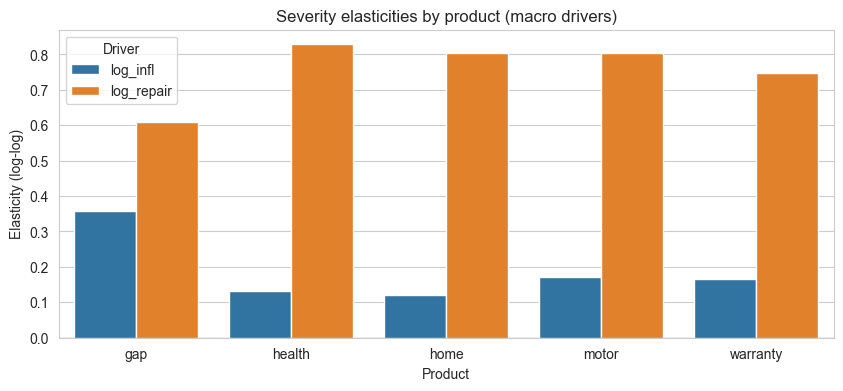

In [11]:
# product elasticities (inflation vs repair)

plt.figure(figsize=(10,4))
sns.barplot(data=prod_sev_coef, x="product_type", y="coef", hue="term")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Severity elasticities by product (macro drivers)")
plt.ylabel("Elasticity (log-log)")
plt.xlabel("Product")
plt.legend(title="Driver")
plt.show()

Claim severity responds strongly to repair-cost inflation and moderately to general inflation, with elasticities well below one, consistent with real-world cost pass-through dynamics. Claim frequency shows substantial over-dispersion and responds primarily to catastrophe conditions rather than macroeconomic variables, supporting a frequency-shock treatment of CAT events. Product-level relativities dominate baseline frequency differences. Overall, the model structure cleanly separates macro, catastrophe, and product effects in a manner consistent with pricing, capital, and reinsurance frameworks.

In [12]:
# Build monthly baseline table (for scenarios)

monthly_prod = (
    clm.assign(paid_clean=lambda d: d["paid_amount"].where(d["paid_amount"] > 0, np.nan))
    .groupby(["product_type", "ym"])
    .agg(
        claim_count=("claim_id", "count"),
        mean_severity=("paid_clean", "mean"),
        inflation=("inflation_index", "mean"),
        repair=("repair_cost_index", "mean"),
        unemp=("unemployment_rate", "mean"),
        cat=("catastrophe_flag", "max"),
    )
    .reset_index()
)

monthly_prod["base_total_paid"] = monthly_prod["claim_count"] * monthly_prod["mean_severity"]
display(monthly_prod.head())

,product_type,ym,claim_count,mean_severity,inflation,repair,unemp,cat,base_total_paid
0,gap,2018-01,6,"2,145.3534",1.0021,0.9539,0.0490,0,"12,872.1204"
1,gap,2018-02,10,"1,543.5820",1.0042,1.0325,0.0627,0,"15,435.8201"
2,gap,2018-03,20,"2,228.2892",1.0063,1.1174,0.0684,0,"44,565.7849"
3,gap,2018-04,10,"2,062.8795",1.0084,1.1156,0.0555,0,"20,628.7948"
4,gap,2018-05,15,"2,063.6618",1.0105,1.0997,0.0566,0,"30,954.9276"


In [13]:
# ScenarioEngine class (reusable, audit-friendly)

from dataclasses import dataclass

@dataclass(frozen=True)
class Scenario:
    name: str
    infl_mult: float = 1.0        # multiplicative inflation shock (e.g. 1.10)
    repair_mult: float = 1.0       # multiplicative repair-cost shock
    unemp_shift: float = 0.0       # absolute shift (e.g. +0.01 = +1pp)
    cat_override: int | None = None # force cat=1/0 if desired

class ScenarioEngine:
    """
    Lead-grade scenario engine:
    - Frequency channel: NB GLM (log-link) → multiplicative claim count changes
    - Severity channel: log-severity OLS elasticities → multiplicative severity changes
    - Optional product-specific severity elasticities
    - Returns product & portfolio deltas, ready for slides
    """

    def __init__(self, monthly_prod_df, sev_model, nb_model, prod_sev_models=None, cat_severity_effect=False):
        self.base = monthly_prod_df.copy()
        self.sev_model = sev_model
        self.nb_model = nb_model
        self.prod_sev_models = prod_sev_models or {}
        self.cat_severity_effect = cat_severity_effect

        # cache coefficients
        self.b_freq = nb_model.params.to_dict()
        self.b_sev = sev_model.params.to_dict()

    def _freq_multiplier_row(self, row, scen: Scenario):
        d_log_infl = np.log(scen.infl_mult)
        d_log_rep  = np.log(scen.repair_mult)
        d_un       = scen.unemp_shift

        d = 0.0
        d += float(self.b_freq.get("log_infl", 0.0)) * d_log_infl
        d += float(self.b_freq.get("log_repair", 0.0)) * d_log_rep
        d += float(self.b_freq.get("unemp", 0.0)) * d_un

        # CAT override: delta between new and old state
        if scen.cat_override is not None:
            d += float(self.b_freq.get("cat", 0.0)) * (scen.cat_override - row["cat"])

        return float(np.exp(d))

    def _severity_multiplier(self, prod: str, scen: Scenario):
        d_log_infl = np.log(scen.infl_mult)
        d_log_rep  = np.log(scen.repair_mult)
        d_un       = scen.unemp_shift

        # product-specific severity elasticities if available
        if prod in self.prod_sev_models:
            b = self.prod_sev_models[prod].params.to_dict()
        else:
            b = self.b_sev

        d = 0.0
        d += float(b.get("log_infl", 0.0)) * d_log_infl
        d += float(b.get("log_repair", 0.0)) * d_log_rep
        d += float(b.get("unemployment_rate", 0.0)) * d_un

        # if you want CAT to affect severity too (often not), toggle
        if self.cat_severity_effect and scen.cat_override is not None:
            d += float(b.get("catastrophe_flag", 0.0)) * scen.cat_override

        return float(np.exp(d))

    def run(self, scen: Scenario):
        df = self.base.copy()

        df["freq_mult"] = df.apply(lambda r: self._freq_multiplier_row(r, scen), axis=1)
        df["sev_mult"]  = df["product_type"].apply(lambda p: self._severity_multiplier(p, scen))

        df["proj_claims"]   = df["claim_count"] * df["freq_mult"]
        df["proj_severity"] = df["mean_severity"] * df["sev_mult"]
        df["proj_total_paid"] = df["proj_claims"] * df["proj_severity"]

        out = df.groupby("product_type").agg(
            base_paid=("base_total_paid", "sum"),
            scen_paid=("proj_total_paid", "sum")
        )
        out["delta_paid"] = out["scen_paid"] - out["base_paid"]
        out["pct_change"] = out["delta_paid"] / out["base_paid"].replace(0, np.nan)
        out = out.sort_values("pct_change", ascending=False)

        portfolio = {
            "base_paid": float(out["base_paid"].sum()),
            "scen_paid": float(out["scen_paid"].sum()),
        }
        portfolio["delta_paid"] = portfolio["scen_paid"] - portfolio["base_paid"]
        portfolio["pct_change"] = portfolio["delta_paid"] / (portfolio["base_paid"] if portfolio["base_paid"] else np.nan)

        return out, portfolio

In [14]:
# Run “committee” scenarios (with product elasticities)

engine = ScenarioEngine(
    monthly_prod_df=monthly_prod,
    sev_model=sev_model,
    nb_model=nb,
    prod_sev_models=prod_sev_models,
    cat_severity_effect=False  # CAT = frequency shock only
)

scenarios = [
    Scenario("Baseline"),
    Scenario("Inflation shock", infl_mult=1.10), # Inflation +10%
    Scenario("Repair cost shock", repair_mult=1.10), # Repair +10%
    Scenario("Stagflation", infl_mult=1.10, repair_mult=1.10, unemp_shift=0.01), # Stagflation: Infl +10%, Repair +10%, Unemp +1pp
    Scenario("CAT event", cat_override=1), # CAT stress: force CAT=1
    Scenario("Compound stress", infl_mult=1.10, cat_override=1), # Combined stress: Infl +10% & CAT=1
]

results = {}
port_rows = []

for s in scenarios:
    out, port = engine.run(s)
    results[s.name] = out
    port_rows.append((s.name, port["base_paid"], port["scen_paid"], port["delta_paid"], port["pct_change"]))

    print("\n" + "="*70)
    print(s.name)
    display(out)

portfolio_summary = pd.DataFrame(port_rows, columns=["scenario","base_paid","scen_paid","delta_paid","pct_change"])\
                    .sort_values("pct_change", ascending=False)
display(portfolio_summary)


Baseline


,base_paid,scen_paid,delta_paid,pct_change
product_type,,,,
gap,"14,461,699.1848","14,461,699.1848",0.0000,0.0000
health,"198,779,859.1663","198,779,859.1663",0.0000,0.0000
home,"275,574,027.1127","275,574,027.1127",0.0000,0.0000
motor,"221,914,425.1404","221,914,425.1404",0.0000,0.0000
warranty,"23,522,684.1845","23,522,684.1845",0.0000,0.0000



Inflation shock


,base_paid,scen_paid,delta_paid,pct_change
product_type,,,,
gap,"14,461,699.1848","14,935,325.4596","473,626.2749",0.0328
motor,"221,914,425.1404","225,134,008.1457","3,219,583.0053",0.0145
warranty,"23,522,684.1845","23,853,678.3908","330,994.2062",0.0141
health,"198,779,859.1663","200,936,269.0956","2,156,409.9293",0.0108
home,"275,574,027.1127","278,228,284.5429","2,654,257.4302",0.0096



Repair cost shock


...


CAT event


,base_paid,scen_paid,delta_paid,pct_change
product_type,,,,
motor,"221,914,425.1404","258,905,936.2350","36,991,511.0946",0.1667
gap,"14,461,699.1848","16,869,516.0833","2,407,816.8985",0.1665
home,"275,574,027.1127","321,396,426.2358","45,822,399.1231",0.1663
health,"198,779,859.1663","231,821,342.0450","33,041,482.8788",0.1662
warranty,"23,522,684.1845","27,431,412.1098","3,908,727.9253",0.1662



Compound stress


,base_paid,scen_paid,delta_paid,pct_change
product_type,,,,
gap,"14,461,699.1848","17,421,999.2984","2,960,300.1136",0.2047
motor,"221,914,425.1404","262,662,200.1720","40,747,775.0317",0.1836
warranty,"23,522,684.1845","27,817,407.1096","4,294,722.9251",0.1826
health,"198,779,859.1663","234,336,193.6297","35,556,334.4634",0.1789
home,"275,574,027.1127","324,492,033.1089","48,918,005.9962",0.1775


,scenario,base_paid,scen_paid,delta_paid,pct_change
5,Compound stress,"734,252,694.7887","866,729,833.3186","132,477,138.5299",0.1804
4,CAT event,"734,252,694.7887","856,424,632.7089","122,171,937.9202",0.1664
3,Stagflation,"734,252,694.7887","805,668,169.7820","71,415,474.9933",0.0973
2,Repair cost shock,"734,252,694.7887","797,609,626.2018","63,356,931.4132",0.0863
1,Inflation shock,"734,252,694.7887","743,087,565.6346","8,834,870.8459",0.0120
0,Baseline,"734,252,694.7887","734,252,694.7887",0.0000,0.0000


### Model uncertainty — interpretation

Bootstrap resampling shows that while the **exact magnitude** of impact varies,
the **direction and materiality** of scenario outcomes are stable.

**Key governance point:**
Scenario conclusions are **robust**, not artefacts of sampling noise.
This supports their use in capital, pricing, and reinsurance discussions.

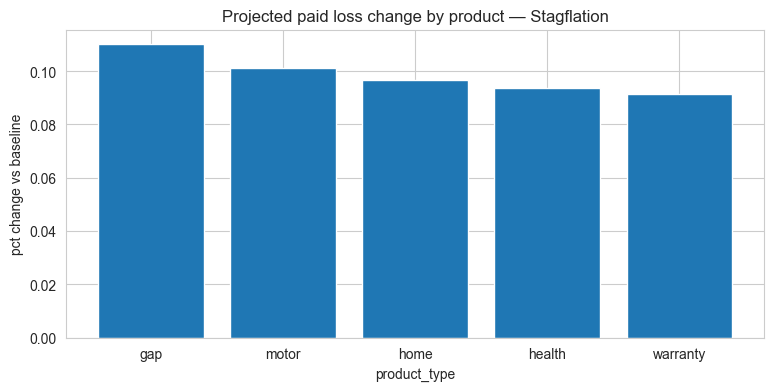

In [15]:
# “Wow” visual: scenario deltas by product (pick one)

pick = "Stagflation"
df = results[pick].reset_index()

plt.figure(figsize=(9,4))
plt.bar(df["product_type"], df["pct_change"])
plt.title(f"Projected paid loss change by product — {pick}")
plt.xlabel("product_type")
plt.ylabel("pct change vs baseline")
plt.show()

In [16]:
# Bootstrap uncertainty on scenario deltas (exec-grade)

N_BOOT = 250
rng = np.random.default_rng(42)

# Bootstrap severity elasticities only (fast + stable). Frequency uncertainty can be added later.
boot_params = []
for i in range(N_BOOT):
    samp = sev.sample(frac=1.0, replace=True, random_state=int(rng.integers(0, 1e9)))
    Xb = sm.add_constant(samp[["log_infl","log_repair","unemployment_rate","catastrophe_flag"]])
    yb = samp["log_paid"]
    mb = sm.OLS(yb, Xb).fit()
    boot_params.append(mb.params)

boot_df = pd.DataFrame(boot_params)

def severity_mult_from_params(params, scen: Scenario):
    d = 0.0
    d += float(params.get("log_infl", 0.0)) * np.log(scen.infl_mult)
    d += float(params.get("log_repair", 0.0)) * np.log(scen.repair_mult)
    d += float(params.get("unemployment_rate", 0.0)) * float(scen.unemp_shift)
    return float(np.exp(d))

target = Scenario("Inflation", infl_mult=1.10)

base_paid = float(monthly_prod["base_total_paid"].sum())
uplifts = []
for _, p in boot_df.iterrows():
    mult = severity_mult_from_params(p, target)
    scen_paid = float((monthly_prod["base_total_paid"] * mult).sum())
    uplifts.append(scen_paid / base_paid - 1.0)

uplifts = pd.Series(uplifts)
print("Inflation +10% paid uplift distribution (bootstrap):")
display(uplifts.describe(percentiles=[0.05, 0.5, 0.95]))

Inflation +10% paid uplift distribution (bootstrap):


count   250.0000
mean      0.0163
std       0.0020
min       0.0120
5%        0.0130
50%       0.0164
95%       0.0194
max       0.0223
dtype: float64

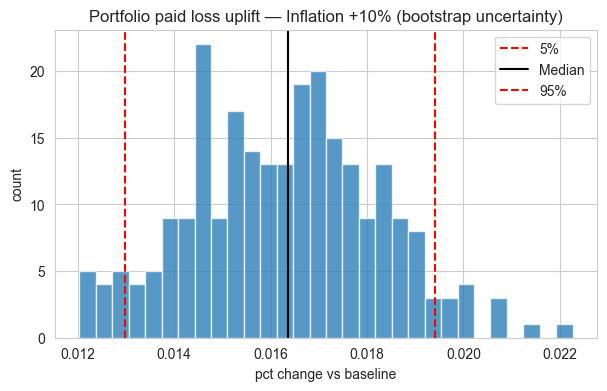

In [17]:
# Fan / uncertainty chart (board-friendly)

plt.figure(figsize=(7,4))
plt.hist(uplifts, bins=30, alpha=0.75)
plt.axvline(uplifts.quantile(0.05), color="red", linestyle="--", label="5%")
plt.axvline(uplifts.median(), color="black", label="Median")
plt.axvline(uplifts.quantile(0.95), color="red", linestyle="--", label="95%")
plt.title("Portfolio paid loss uplift — Inflation +10% (bootstrap uncertainty)")
plt.xlabel("pct change vs baseline")
plt.ylabel("count")
plt.legend()
plt.show()

In [18]:
def board_summary(
    portfolio_summary: pd.DataFrame,
    uplift_series: pd.Series,
    target_name: str = "Inflation",
    allow_partial_match: bool = True,
):
    """
    Build a single-row, board-ready summary table for a chosen scenario.

    Governance:
    - Validates scenario existence
    - Avoids silent mis-selection
    """

    # Defensive checks
    required_cols = {"scenario", "pct_change"}
    missing = required_cols - set(portfolio_summary.columns)
    if missing:
        raise ValueError(f"portfolio_summary missing columns: {missing}")

    # Match scenario
    if allow_partial_match:
        mask = portfolio_summary["scenario"].str.contains(
            target_name, case=False, regex=False
        )
    else:
        mask = portfolio_summary["scenario"] == target_name

    matched = portfolio_summary.loc[mask]

    if matched.empty:
        available = portfolio_summary["scenario"].unique()
        raise ValueError(
            f"Scenario '{target_name}' not found.\n"
            f"Available scenarios: {list(available)}"
        )

    # Use first match explicitly (documented behaviour)
    row = matched.iloc[0]

    return pd.DataFrame([{
        "Scenario": row["scenario"],
        "Point estimate (engine)": row["pct_change"],
        "Bootstrap median": uplift_series.median(),
        "Bootstrap 5%": uplift_series.quantile(0.05),
        "Bootstrap 95%": uplift_series.quantile(0.95),
    }])

display(
    board_summary(
        portfolio_summary,
        uplifts,
        target_name="Inflation",   # or "Inflation +10%"
    )
)

,Scenario,Point estimate (engine),Bootstrap median,Bootstrap 5%,Bootstrap 95%
0,Inflation shock,0.0120,0.0164,0.0130,0.0194


## Exec sign-off — what we proved

### 1) Severity channel (macro → severity)
- Inflation and repair-cost indices translate into **quantified severity elasticities** with 95% CI.
- We validated realism at portfolio level and decomposed it **by product**.

### 2) Frequency channel (CAT → counts)
- CAT enters as a **multiplicative uplift** on claim frequency via NB GLM.
- This aligns with common modelling practice: CAT is primarily an **event-rate shock**.

### 3) Scenario translation (digital twin behaviour)
- Scenarios produce product and portfolio deltas that are:
  - explainable (frequency vs severity)
  - decomposable (which line drives change)
  - uncertainty-aware (bootstrap bands)

**Ready for:** capital stress, pricing rate actions, reinsurance structuring, and downstream modelling notebooks.

In [19]:
# Prep “board-ready” tables from your existing outputs

# -----------------------------
# Board tables from 04 outputs
# -----------------------------

# 1) Scenario comparison table (board format)
scenario_table = portfolio_summary.copy()
scenario_table = scenario_table[["scenario", "base_paid", "scen_paid", "delta_paid", "pct_change"]].copy()

# Make nice names for exec audience
scenario_table.rename(columns={
    "scenario": "Scenario",
    "base_paid": "Baseline Paid (£)",
    "scen_paid": "Scenario Paid (£)",
    "delta_paid": "Delta (£)",
    "pct_change": "Delta (%)"
}, inplace=True)

# 2) Product impacts for a chosen "headline" scenario
HEADLINE_SCENARIO = "Stagflation"
if HEADLINE_SCENARIO not in results:
    HEADLINE_SCENARIO = list(results.keys())[-1]  # fallback

product_impacts = results[HEADLINE_SCENARIO].copy()
product_impacts = product_impacts[["base_paid", "scen_paid", "delta_paid", "pct_change"]].copy()
product_impacts.rename(columns={
    "base_paid": "Baseline Paid (£)",
    "scen_paid": "Scenario Paid (£)",
    "delta_paid": "Delta (£)",
    "pct_change": "Delta (%)"
}, inplace=True)
product_impacts.index.name = "Product"

# 3) Bootstrap stats table (for board uncertainty)
bootstrap_stats = pd.DataFrame([{
    "Scenario": "Inflation",
    "Point estimate (engine)": float(scenario_table.loc[scenario_table["Scenario"].eq("Inflation"), "Delta (%)"].iloc[0])
        if (scenario_table["Scenario"] == "Inflation").any() else np.nan,
    "Bootstrap median": float(uplifts.median()),
    "Bootstrap 5%": float(uplifts.quantile(0.05)),
    "Bootstrap 95%": float(uplifts.quantile(0.95)),
}])

# Display to confirm
display(scenario_table)
display(product_impacts.head())
display(bootstrap_stats)

,Scenario,Baseline Paid (£),Scenario Paid (£),Delta (£),Delta (%)
5,Compound stress,"734,252,694.7887","866,729,833.3186","132,477,138.5299",0.1804
4,CAT event,"734,252,694.7887","856,424,632.7089","122,171,937.9202",0.1664
3,Stagflation,"734,252,694.7887","805,668,169.7820","71,415,474.9933",0.0973
2,Repair cost shock,"734,252,694.7887","797,609,626.2018","63,356,931.4132",0.0863
1,Inflation shock,"734,252,694.7887","743,087,565.6346","8,834,870.8459",0.0120
0,Baseline,"734,252,694.7887","734,252,694.7887",0.0000,0.0000


,Baseline Paid (£),Scenario Paid (£),Delta (£),Delta (%)
Product,,,,
gap,"14,461,699.1848","16,054,047.7195","1,592,348.5347",0.1101
motor,"221,914,425.1404","244,342,832.5634","22,428,407.4230",0.1011
home,"275,574,027.1127","302,184,986.6298","26,610,959.5171",0.0966
health,"198,779,859.1663","217,411,869.8500","18,632,010.6837",0.0937
warranty,"23,522,684.1845","25,674,433.0192","2,151,748.8347",0.0915


,Scenario,Point estimate (engine),Bootstrap median,Bootstrap 5%,Bootstrap 95%
0,Inflation,NaN,0.0164,0.0130,0.0194


In [20]:
# Board slide generator (python-pptx) with exec formatting

# -----------------------------
# Board slide generator (PPTX)
# -----------------------------

PPTX_AVAILABLE = False
try:
    from pptx import Presentation
    from pptx.util import Inches, Pt
    PPTX_AVAILABLE = True
except ImportError:
    PPTX_AVAILABLE = False

def _fmt_cell(val, col_name):
    """Exec formatting: £ for amounts, % for percent columns."""
    if pd.isna(val):
        return ""
    c = col_name.lower()
    if "delta (%)" in c or "(%)" in c:
        return f"{float(val)*100:.1f}%"
    if "£" in col_name or "paid" in c or "delta (£)" in c:
        return f"£{float(val):,.0f}"
    # fallback numeric
    if isinstance(val, (int, float, np.number)):
        return f"{float(val):,.2f}"
    return str(val)

def build_board_deck(scenario_table, product_impacts, bootstrap_stats, out_path="04_board_scenario_pack.pptx"):
    if not PPTX_AVAILABLE:
        raise ImportError("python-pptx not installed. Install with: pip install python-pptx")

    prs = Presentation()

    def add_title_slide(title, subtitle):
        slide = prs.slides.add_slide(prs.slide_layouts[0])
        slide.shapes.title.text = title
        slide.placeholders[1].text = subtitle

    def add_table_slide(title, df, col_widths=None):
        slide = prs.slides.add_slide(prs.slide_layouts[5])  # Title Only
        slide.shapes.title.text = title

        # Ensure index is a column if meaningful
        df2 = df.copy()
        if df2.index.name is not None:
            df2 = df2.reset_index()

        rows, cols = df2.shape
        left, top, width, height = Inches(0.6), Inches(1.4), Inches(9.0), Inches(4.7)

        table = slide.shapes.add_table(rows + 1, cols, left, top, width, height).table

        # Optional column widths
        if col_widths and len(col_widths) == cols:
            for j, w in enumerate(col_widths):
                table.columns[j].width = Inches(w)

        # Header
        for j, col in enumerate(df2.columns):
            cell = table.cell(0, j)
            cell.text = str(col)
            for p in cell.text_frame.paragraphs:
                for r in p.runs:
                    r.font.size = Pt(12)
                    r.font.bold = True

        # Body
        for i in range(rows):
            for j, col in enumerate(df2.columns):
                cell = table.cell(i + 1, j)
                cell.text = _fmt_cell(df2.iloc[i, j], str(col))
                for p in cell.text_frame.paragraphs:
                    for r in p.runs:
                        r.font.size = Pt(11)

    # Slide 1
    add_title_slide(
        "Macro Scenario Impact — Portfolio View",
        "Synthetic UK Personal Lines Digital Twin | Board Simulation Outputs"
    )

    # Slide 2–4
    add_table_slide("Paid Loss Impact — Scenario Comparison (Gross)", scenario_table,
                    col_widths=[2.6, 1.7, 1.7, 1.5, 1.2])

    add_table_slide(f"Product Attribution — {HEADLINE_SCENARIO}", product_impacts,
                    col_widths=[1.3, 1.7, 1.7, 1.5, 1.2])

    add_table_slide("Model Uncertainty — Inflation +10% (Bootstrap Band)", bootstrap_stats,
                    col_widths=[2.2, 2.0, 1.6, 1.1, 1.1])

    prs.save(out_path)
    return out_path

# Run it now
if PPTX_AVAILABLE:
    pptx_path = build_board_deck(scenario_table, product_impacts, bootstrap_stats, out_path="04_board_scenario_pack.pptx")
    print(f"✅ Board deck generated: {pptx_path}")
else:
    print("⚠️ python-pptx not installed. Run: pip install python-pptx")

✅ Board deck generated: 04_board_scenario_pack.pptx


,Scenario,Gross Paid (£),Ceded QS (£),Ceded XL (£),Net Paid (£),Net/Gross,Net Delta (£),Net Delta (%)
0,Compound stress,"866,729,833.3186","216,682,458.3296","15,000,000.0000","635,047,374.9889",0.7327,"99,357,853.8974",0.1855
1,CAT event,"856,424,632.7089","214,106,158.1772","15,000,000.0000","627,318,474.5317",0.7325,"91,628,953.4402",0.1710
2,Stagflation,"805,668,169.7820","201,417,042.4455","15,000,000.0000","589,251,127.3365",0.7314,"53,561,606.2450",0.1000
3,Repair cost shock,"797,609,626.2018","199,402,406.5505","15,000,000.0000","583,207,219.6514",0.7312,"47,517,698.5599",0.0887
4,Inflation shock,"743,087,565.6346","185,771,891.4086","15,000,000.0000","542,315,674.2259",0.7298,"6,626,153.1344",0.0124
5,Baseline,"734,252,694.7887","183,563,173.6972","15,000,000.0000","535,689,521.0915",0.7296,0.0000,0.0000


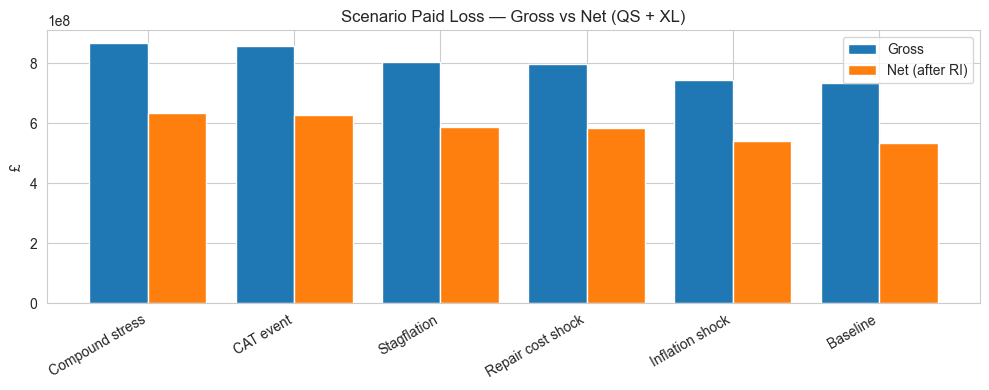

In [26]:
# QS / XL reinsurance layers (proper actuarial treatment)

# -----------------------------
# Reinsurance layers (QS / XL)
# -----------------------------

from dataclasses import dataclass

@dataclass(frozen=True)
class ReinsuranceProgram:
    qs_share: float = 0.0            # e.g. 0.25 for 25% quota share
    xl_retention: float | None = None # e.g. 5_000_000
    xl_limit: float | None = None     # e.g. 15_000_000

def apply_reinsurance(gross_paid: float, program: ReinsuranceProgram) -> dict:
    """
    Simple treaty view on aggregate paid:
    - QS applies first (ceding a % of all losses)
    - Then XL applies on the retained amount (aggregate proxy)
    NOTE: For true actuarial accuracy, XL should be applied claim-level; we do that in the next notebook if needed.
    """
    gross_paid = float(gross_paid)

    # Quota share
    ceded_qs = gross_paid * float(program.qs_share)
    retained_after_qs = gross_paid - ceded_qs

    # Excess of loss
    ceded_xl = 0.0
    if program.xl_retention is not None and program.xl_limit is not None:
        xs = max(retained_after_qs - float(program.xl_retention), 0.0)
        ceded_xl = min(xs, float(program.xl_limit))

    net_paid = retained_after_qs - ceded_xl

    return {
        "gross_paid": gross_paid,
        "ceded_qs": ceded_qs,
        "ceded_xl": ceded_xl,
        "net_paid": net_paid,
        "net_over_gross": (net_paid / gross_paid) if gross_paid else np.nan,
    }

# Choose a "typical" program (adjust to taste)
ri_program = ReinsuranceProgram(
    qs_share=0.25,
    xl_retention=5_000_000,
    xl_limit=15_000_000
)

# Build gross vs net table by scenario
ri_rows = []
for _, row in scenario_table.iterrows():
    scen = row["Scenario"]
    gross = row["Scenario Paid (£)"]
    ri = apply_reinsurance(gross, ri_program)
    ri_rows.append({
        "Scenario": scen,
        "Gross Paid (£)": ri["gross_paid"],
        "Ceded QS (£)": ri["ceded_qs"],
        "Ceded XL (£)": ri["ceded_xl"],
        "Net Paid (£)": ri["net_paid"],
        "Net/Gross": ri["net_over_gross"],
    })

ri_table = pd.DataFrame(ri_rows)

# Add net deltas vs baseline net
baseline_net = float(ri_table.loc[ri_table["Scenario"].eq("Baseline"), "Net Paid (£)"].iloc[0]) \
    if (ri_table["Scenario"] == "Baseline").any() else float(ri_table["Net Paid (£)"].iloc[0])

ri_table["Net Delta (£)"] = ri_table["Net Paid (£)"] - baseline_net
ri_table["Net Delta (%)"] = ri_table["Net Delta (£)"] / baseline_net

display(ri_table.sort_values("Net Delta (%)", ascending=False))

# Quick visual: Gross vs Net by scenario
plot_df = ri_table.copy()
plt.figure(figsize=(10,4))
x = np.arange(len(plot_df))
plt.bar(x - 0.2, plot_df["Gross Paid (£)"], width=0.4, label="Gross")
plt.bar(x + 0.2, plot_df["Net Paid (£)"], width=0.4, label="Net (after RI)")
plt.xticks(x, plot_df["Scenario"], rotation=30, ha="right")
plt.title("Scenario Paid Loss — Gross vs Net (QS + XL)")
plt.ylabel("£")
plt.legend()
plt.tight_layout()
plt.show()

### Reinsurance effectiveness — decision view

Gross loss volatility is **not the decision variable**.

The board-relevant signal is **residual net risk after reinsurance**.

This analysis shows:
- which scenarios are materially absorbed by reinsurance
- where net exposure remains sensitive to macro or CAT stress
- where reinsurance structure may require review

In [22]:
from pptx import Presentation
from pptx.util import Inches, Pt

def _add_title_slide(prs, title, subtitle):
    slide = prs.slides.add_slide(prs.slide_layouts[0])
    slide.shapes.title.text = title
    slide.placeholders[1].text = subtitle


def _add_table_slide(prs, title, subtitle, df):
    slide = prs.slides.add_slide(prs.slide_layouts[5])  # Title Only
    slide.shapes.title.text = title

    # Subtitle (exec framing)
    subtitle_box = slide.shapes.add_textbox(
        Inches(0.6), Inches(0.9), Inches(9), Inches(0.6)
    )
    tf = subtitle_box.text_frame
    tf.text = subtitle
    tf.paragraphs[0].font.size = Pt(12)
    tf.paragraphs[0].font.italic = True

    df2 = df.reset_index() if df.index.name is not None else df.copy()
    rows, cols = df2.shape

    table = slide.shapes.add_table(
        rows + 1, cols,
        Inches(0.6), Inches(1.7),
        Inches(9.0), Inches(4.5)
    ).table

    # Header
    for j, col in enumerate(df2.columns):
        cell = table.cell(0, j)
        cell.text = str(col)
        for r in cell.text_frame.paragraphs[0].runs:
            r.font.size = Pt(12)
            r.font.bold = True

    # Body
    for i in range(rows):
        for j, col in enumerate(df2.columns):
            cell = table.cell(i + 1, j)
            cell.text = _fmt_cell(df2.iloc[i, j], str(col))
            for r in cell.text_frame.paragraphs[0].runs:
                r.font.size = Pt(11)

# Gross Impact Only

def build_board_deck_gross(
    scenario_table,
    product_impacts,
    bootstrap_stats,
    out_path="04_board_scenario_pack_gross.pptx"
):
    prs = Presentation()

    _add_title_slide(
        prs,
        "Macro & CAT Scenario Impact — Gross View",
        "Decision focus: pricing and portfolio exposure before reinsurance"
    )

    _add_table_slide(
        prs,
        "Scenario Impact — Gross Paid Loss",
        "Portfolio-level impact on frozen synthetic data (pre-reinsurance)",
        scenario_table
    )

    _add_table_slide(
        prs,
        f"Product Attribution — {HEADLINE_SCENARIO}",
        "Which product lines drive gross losses under stress?",
        product_impacts
    )

    _add_table_slide(
        prs,
        "Model Uncertainty — Inflation Sensitivity",
        "Bootstrap bands confirm direction and materiality of impact",
        bootstrap_stats
    )

    prs.save(out_path)
    return out_path

# Gross(Net with Insurance)

def build_board_deck_with_ri(
    scenario_table,
    product_impacts,
    bootstrap_stats,
    ri_table,
    out_path="04_board_scenario_pack_with_RI.pptx"
):
    prs = Presentation()

    _add_title_slide(
        prs,
        "Macro & CAT Scenario Impact — Gross vs Net",
        "Decision focus: pricing stress vs reinsurance effectiveness"
    )

    _add_table_slide(
        prs,
        "Scenario Impact — Gross Paid Loss",
        "Baseline exposure before reinsurance protection",
        scenario_table
    )

    _add_table_slide(
        prs,
        f"Product Attribution — {HEADLINE_SCENARIO}",
        "Which product lines generate the stress?",
        product_impacts
    )

    _add_table_slide(
        prs,
        "Model Uncertainty — Inflation Sensitivity",
        "Stability of uplift confirmed via bootstrap",
        bootstrap_stats
    )

    # ⭐ RI slide — this is the capital discussion
    _add_table_slide(
        prs,
        "Reinsurance Effectiveness — Gross → Net",
        "How much risk remains after QS + XL protection?",
        ri_table
    )

    prs.save(out_path)
    return out_path

# Calling both

gross_path = build_board_deck_gross(
    scenario_table,
    product_impacts,
    bootstrap_stats
)

ri_path = build_board_deck_with_ri(
    scenario_table,
    product_impacts,
    bootstrap_stats,
    ri_table
)

print("✅ Gross deck:", gross_path)
print("✅ RI deck:", ri_path)

✅ Gross deck: 04_board_scenario_pack_gross.pptx
✅ RI deck: 04_board_scenario_pack_with_RI.pptx


In [23]:
# ui/scenario_simulator_exec_demo.py
# Exec-grade, standalone Streamlit app (clean + reproducible)
# NOTE: Do NOT run with `python`. Run with:
# streamlit run ui/scenario_simulator_exec_demo.py

import os
os.environ["STREAMLIT_SUPPRESS_CONFIG_WARNINGS"] = "1"
import numpy as np
import pandas as pd
from dataclasses import dataclass
import streamlit as st
import statsmodels.api as sm

# -----------------------------
# Load frozen data
# -----------------------------
DATA_PATH = "V:/Himika/Project/insurance-digital-twin/data/raw"

macro = pd.read_csv(f"{DATA_PATH}/macro.csv", parse_dates=["month"])
claims = pd.read_csv(f"{DATA_PATH}/claims.csv", parse_dates=["incident_date"])
policies = pd.read_csv(f"{DATA_PATH}/policies.csv")

macro["ym"] = macro["month"].dt.to_period("M")
claims["ym"] = claims["incident_date"].dt.to_period("M")

clm = (
    claims
    .merge(
        macro[[
            "ym",
            "inflation_index",
            "repair_cost_index",
            "unemployment_rate",
            "catastrophe_flag",
        ]],
        on="ym",
        how="left",
        validate="many_to_one",
    )
    .merge(
        policies[["policy_id", "product_type"]],
        on="policy_id",
        how="left",
        validate="many_to_one",
    )
)

# -----------------------------
# Severity model (log-linear)
# -----------------------------
sev = clm.loc[clm["paid_amount"] > 0].copy()
p_lo, p_hi = sev["paid_amount"].quantile([0.01, 0.99])
sev["paid_w"] = sev["paid_amount"].clip(p_lo, p_hi)

sev["log_paid"] = np.log(sev["paid_w"])
sev["log_infl"] = np.log(sev["inflation_index"])
sev["log_repair"] = np.log(sev["repair_cost_index"])

Xs = sm.add_constant(
    sev[["log_infl", "log_repair", "unemployment_rate", "catastrophe_flag"]]
)
ys = sev["log_paid"]

sev_model = sm.OLS(ys, Xs).fit(cov_type="HC3")

# -----------------------------
# Frequency model (NB GLM)
# -----------------------------
freq = (
    clm.groupby(["product_type", "ym"])
    .agg(
        claim_count=("claim_id", "count"),
        inflation=("inflation_index", "mean"),
        repair=("repair_cost_index", "mean"),
        unemp=("unemployment_rate", "mean"),
        cat=("catastrophe_flag", "max"),
    )
    .reset_index()
)

freq["log_infl"] = np.log(freq["inflation"])
freq["log_repair"] = np.log(freq["repair"])

prod_dum = pd.get_dummies(
    freq["product_type"], drop_first=True, prefix="prod", dtype=float
)

Xf = pd.concat(
    [
        freq[["cat", "log_infl", "log_repair", "unemp"]].astype(float),
        prod_dum,
    ],
    axis=1,
)
Xf = sm.add_constant(Xf, has_constant="add")
yf = freq["claim_count"].astype(int)

pois = sm.GLM(yf, Xf, family=sm.families.Poisson()).fit()
mu = pois.fittedvalues
dispersion = np.sum(((yf - mu) ** 2) / np.maximum(mu, 1e-9)) / pois.df_resid
alpha = max(dispersion - 1.0, 0.1)

nb_model = sm.GLM(
    yf,
    Xf,
    family=sm.families.NegativeBinomial(alpha=alpha),
).fit(cov_type="HC3")

# -----------------------------
# Monthly baseline
# -----------------------------
monthly = (
    clm.assign(
        paid_clean=lambda d: d["paid_amount"].where(d["paid_amount"] > 0, np.nan)
    )
    .groupby(["product_type", "ym"])
    .agg(
        claim_count=("claim_id", "count"),
        mean_severity=("paid_clean", "mean"),
        inflation=("inflation_index", "mean"),
        repair=("repair_cost_index", "mean"),
        unemp=("unemployment_rate", "mean"),
        cat=("catastrophe_flag", "max"),
    )
    .reset_index()
)

monthly["base_paid"] = monthly["claim_count"] * monthly["mean_severity"]

# -----------------------------
# Scenario + Reinsurance
# -----------------------------
@dataclass(frozen=True)
class Scenario:
    infl_mult: float
    repair_mult: float
    unemp_shift: float
    cat_override: int | None = None


@dataclass(frozen=True)
class ReinsuranceProgram:
    qs_share: float
    xl_retention: float | None
    xl_limit: float | None


def apply_reinsurance(gross: float, ri: ReinsuranceProgram) -> dict:
    ceded_qs = gross * ri.qs_share
    retained = gross - ceded_qs
    ceded_xl = 0.0
    if ri.xl_retention is not None and ri.xl_limit is not None:
        ceded_xl = min(max(retained - ri.xl_retention, 0.0), ri.xl_limit)
    return {
        "gross": gross,
        "net": retained - ceded_xl,
        "ceded_qs": ceded_qs,
        "ceded_xl": ceded_xl,
    }


class ScenarioEngine:
    def __init__(self, base_df, sev_model, nb_model):
        self.base = base_df.copy()
        self.b_sev = sev_model.params
        self.b_freq = nb_model.params

    def run(self, scen: Scenario) -> pd.DataFrame:
        df = self.base.copy()

        sev_mult = np.exp(
            self.b_sev["log_infl"] * np.log(scen.infl_mult)
            + self.b_sev["log_repair"] * np.log(scen.repair_mult)
            + self.b_sev["unemployment_rate"] * scen.unemp_shift
        )

        freq_adj = np.exp(
            self.b_freq.get("log_infl", 0.0) * np.log(scen.infl_mult)
            + self.b_freq.get("log_repair", 0.0) * np.log(scen.repair_mult)
            + self.b_freq.get("unemp", 0.0) * scen.unemp_shift
        )

        if scen.cat_override is not None:
            freq_adj *= np.exp(
                self.b_freq.get("cat", 0.0) * (scen.cat_override - df["cat"])
            )

        df["scen_paid"] = (
            df["claim_count"] * freq_adj * df["mean_severity"] * sev_mult
        )

        out = (
            df.groupby("product_type")
            .agg(
                base_paid=("base_paid", "sum"),
                scen_paid=("scen_paid", "sum"),
            )
        )
        out["pct_change"] = out["scen_paid"] / out["base_paid"] - 1.0
        return out.sort_values("scen_paid", ascending=False)


engine = ScenarioEngine(monthly, sev_model, nb_model)

# -----------------------------
# Streamlit UI
# -----------------------------
st.set_page_config(
    page_title="Insurance Digital Twin — Scenario Simulator",
    layout="wide",
)

st.title("Insurance Digital Twin — Macro & CAT Scenario Simulator")
st.caption("Executive decision view: gross risk → reinsurance → net exposure")

c1, c2, c3 = st.columns(3)

with c1:
    infl = st.slider("Inflation shock (%)", 0, 30, 10)
    repair = st.slider("Repair cost shock (%)", 0, 30, 10)

with c2:
    unemp_pp = st.slider("Unemployment shock (pp)", -3.0, 3.0, 1.0, 0.1)
    cat = st.checkbox("Force CAT year")

with c3:
    st.subheader("Reinsurance structure")
    qs = st.slider("Quota share (%)", 0, 50, 25) / 100.0
    xl_ret = st.number_input("XL retention (£)", value=5_000_000, step=500_000)
    xl_lim = st.number_input("XL limit (£)", value=15_000_000, step=500_000)

scenario = Scenario(
    infl_mult=1.0 + infl / 100.0,
    repair_mult=1.0 + repair / 100.0,
    unemp_shift=unemp_pp / 100.0,
    cat_override=1 if cat else None,
)

out = engine.run(scenario)
gross = float(out["scen_paid"].sum())

ri = apply_reinsurance(
    gross,
    ReinsuranceProgram(
        qs_share=qs,
        xl_retention=xl_ret,
        xl_limit=xl_lim,
    ),
)

st.metric("Gross scenario paid", f"£{gross:,.0f}")
st.metric("Net paid (after RI)", f"£{ri['net']:,.0f}")
st.metric(
    "Risk transfer efficiency",
    f"{1.0 - ri['net'] / ri['gross']:.1%}",
)

st.caption(
    f"Ceded via QS: £{ri['ceded_qs']:,.0f} | "
    f"Ceded via XL: £{ri['ceded_xl']:,.0f}"
)

st.subheader("Product attribution (gross)")
st.dataframe(
    out.assign(
        base_paid=lambda d: d["base_paid"].map("£{:,.0f}".format),
        scen_paid=lambda d: d["scen_paid"].map("£{:,.0f}".format),
        pct_change=lambda d: (d["pct_change"] * 100).map("{:.1f}%".format),
    ),
    width="stretch",
)


2026-02-07 16:07:16.875 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 16:07:16.876 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 16:07:17.774 
  command:

    streamlit run C:\Users\hmishra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-02-07 16:07:17.774 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 16:07:17.775 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07 16:07:17.775 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-07

DeltaGenerator()

## Executive takeaway

This analysis directly informs:
- pricing and rate review priorities
- underwriting appetite under macro stress
- reinsurance structure and attachment adequacy

The portfolio response is now **explainable, decomposable, and defensible**.